In [442]:
import os
import numpy as np
import pandas as pd
import pickle as pkl
import matplotlib.pyplot as plt
import seaborn as sns

path = '/home/mina-joojoo/Desktop/tool_wearing/'
dataset = pd.read_csv(path + 'correlated_dataset.csv')

In [443]:
dataset.describe()

,VB,machine,tool,C,torque_x_mean,torque_x_max,torque_x_min,torque_x_rms,torque_y_mean,torque_y_max,...,fx_sens_rms,fx_sens_skew,fy_sens_mean,fy_sens_max,fy_sens_rms,fz_sens_mean,fx_mean,fx_rms,fy_max,log_C
count,6418.000000,6418.000000,6418.000000,6418.000000,1856.000000,1856.000000,1856.000000,1856.000000,1856.000000,1856.000000,...,6418.000000,6418.000000,6418.000000,6418.000000,6418.000000,6418.000000,4562.000000,4562.000000,4562.000000,6418.000000
mean,0.498981,1.987847,4.968059,0.408794,0.460133,0.473887,0.453379,0.460371,0.574090,0.551257,...,0.433052,0.511628,0.306669,0.283839,0.307563,0.657514,0.575521,0.428492,0.365327,0.911474
std,0.192033,0.752436,2.396248,0.252341,0.201016,0.204136,0.192763,0.200983,0.249893,0.223301,...,0.200694,0.075603,0.220102,0.176312,0.199240,0.205144,0.170436,0.157979,0.142779,0.077313
min,0.000000,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.350318,1.000000,3.000000,0.200048,0.293444,0.301370,0.297694,0.293497,0.372253,0.388263,...,0.270910,0.468962,0.109987,0.141577,0.155073,0.494556,0.454018,0.311315,0.277526,0.883523
50%,0.484076,2.000000,5.000000,0.394004,0.442969,0.455969,0.437107,0.443407,0.628494,0.572346,...,0.433072,0.511493,0.261154,0.252694,0.271151,0.710781,0.589292,0.408604,0.337758,0.932584
75%,0.617834,3.000000,7.000000,0.588395,0.625273,0.643836,0.607967,0.625761,0.793413,0.717041,...,0.588783,0.555747,0.471816,0.418689,0.451876,0.830853,0.702153,0.533294,0.429330,0.961611
max,1.000000,3.000000,9.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,...,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


In [444]:
dataset.columns

Index(['VB', 'machine', 'tool', 'C', 'torque_x_mean', 'torque_x_max',
       'torque_x_min', 'torque_x_rms', 'torque_y_mean', 'torque_y_max',
       'torque_y_min', 'torque_y_rms', 'torque_z_std', 'torque_z_min',
       'f_sens_mean', 'f_sens_max', 'f_sens_min', 'f_sens_rms', 'fx_sens_mean',
       'fx_sens_rms', 'fx_sens_skew', 'fy_sens_mean', 'fy_sens_max',
       'fy_sens_rms', 'fz_sens_mean', 'fx_mean', 'fx_rms', 'fy_max', 'log_C'],
      dtype='object')

In [445]:
null_counts = dataset.isnull().sum()
print(list(null_counts))

[0, 0, 0, 0, 4562, 4562, 4562, 4562, 4562, 4562, 4562, 4562, 4562, 4562, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1856, 1856, 1856, 0]


Data is structurally missed, not randomly.

In [446]:
dataset

,VB,machine,tool,C,torque_x_mean,torque_x_max,torque_x_min,torque_x_rms,torque_y_mean,torque_y_max,...,fx_sens_rms,fx_sens_skew,fy_sens_mean,fy_sens_max,fy_sens_rms,fz_sens_mean,fx_mean,fx_rms,fy_max,log_C
0,0.000000,1.0,1.0,0.000000,0.113359,0.097848,0.060797,0.113217,0.914575,0.726687,...,0.000000,0.564510,0.007965,0.000000,0.011185,0.969655,NaN,NaN,NaN,0.000000
1,0.000000,1.0,1.0,0.000774,0.118073,0.136987,0.104822,0.118800,0.912981,0.720257,...,0.004217,0.564362,0.008839,0.000755,0.010296,0.967939,NaN,NaN,NaN,0.481522
2,0.006369,1.0,1.0,0.001547,0.132263,0.148728,0.106918,0.132783,0.907463,0.733118,...,0.007958,0.564056,0.011123,0.001772,0.009257,0.964344,NaN,NaN,NaN,0.531647
3,0.012739,1.0,1.0,0.002321,0.077424,0.090020,0.060797,0.078028,0.907515,0.723472,...,0.010765,0.564008,0.013739,0.007374,0.008654,0.962159,NaN,NaN,NaN,0.560980
4,0.019108,1.0,1.0,0.003095,0.146385,0.142857,0.146751,0.146683,0.902601,0.733118,...,0.012686,0.563959,0.016059,0.005550,0.009421,0.958551,NaN,NaN,NaN,0.581795
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6413,0.987261,3.0,9.0,0.662089,NaN,NaN,NaN,NaN,NaN,NaN,...,0.788777,0.400178,0.717210,0.686303,0.714535,0.259497,0.564412,0.411767,0.408763,0.970153
6414,0.993631,3.0,9.0,0.662863,NaN,NaN,NaN,NaN,NaN,NaN,...,0.789091,0.399290,0.717495,0.696564,0.714081,0.269923,0.488684,0.483559,0.407784,0.970237
6415,0.993631,3.0,9.0,0.663443,NaN,NaN,NaN,NaN,NaN,NaN,...,0.791689,0.400237,0.719864,0.684370,0.719091,0.269183,0.372683,0.593544,0.410069,0.970301
6416,0.993631,3.0,9.0,0.664217,NaN,NaN,NaN,NaN,NaN,NaN,...,0.794456,0.401509,0.724149,0.709529,0.719496,0.264850,0.359817,0.605770,0.410940,0.970385


In [447]:
from sklearn.model_selection import train_test_split
rest = dataset[dataset['tool'] != 8]
test_set = dataset[dataset['tool'] == 8]
train_set, validation_set = train_test_split(rest,random_state=42,test_size=0.2)
train_set = train_set.drop('tool', axis=1)
validation_set = validation_set.drop('tool', axis=1)
test_set = test_set.drop('tool', axis=1)

In [448]:
# mask-aware neural network loss
X = train_set.drop(columns=["VB"])
y = train_set["VB"].values
mask = ~X.isna()
mask = mask.astype(float)
X = X.fillna(0)

X_validation = validation_set.drop(columns=["VB"])
y_validation = validation_set["VB"].values
mask_validation = ~X_validation.isna()
mask_validation = mask_validation.astype(float)
X_validation = X_validation.fillna(0)

X_validation_tensor = torch.tensor(X_validation.values, dtype=torch.float32)
y_validation_tensor = torch.tensor(y_validation, dtype=torch.float32)
mask_validation_tensor = torch.tensor(mask_validation.values, dtype=torch.float32)

X_test = test_set.drop(columns=["VB"])
y_test = test_set["VB"].values
mask_test = ~X_test.isna()
mask_test = mask_test.astype(float)
X_test = X_test.fillna(0)

X_test_tensor = torch.tensor(X_test.values, dtype=torch.float32)
y_test_tensor = torch.tensor(y_test, dtype=torch.float32)
mask_test_tensor = torch.tensor(mask_test.values, dtype=torch.float32)

In [462]:
import torch
import torch.nn as nn

class predict_wear(nn.Module):
    def __init__(self, input_dim):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, 64),
            nn.ReLU(),
            nn.Linear(64, 16),
            nn.ReLU(),
            nn.Linear(16,1),
)


    def forward(self, x):
        return self.net(x)

In [463]:
def masked_mse_loss(pred, target, mask):
    valid_counts = mask.sum(dim=1, keepdim=True) 
    weights = valid_counts / mask.shape[1]
    loss = weights * (pred - target)**2
    return loss.mean()

In [468]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

model = predict_wear(input_dim=X.shape[1])

optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
epochs = 80

train_losses = []
val_losses = []
val_mae = []
os.makedirs('models',exist_ok=True, mode=0o777)
for epoch in range(epochs):
    x_batch = torch.tensor(X.values, dtype=torch.float32)
    y_batch = torch.tensor(y.reshape(-1,1), dtype=torch.float32)
    mask_batch = torch.tensor(mask.values, dtype=torch.float32)

    pred = model(x_batch)
    loss = masked_mse_loss(pred, y_batch, mask_batch)
    train_losses.append(loss.item())
    
    model.eval()
    with torch.no_grad():
        val_pred = model(X_validation_tensor)
        val_loss = masked_mse_loss(val_pred, y_validation_tensor, mask_validation_tensor)
        val_losses.append(val_loss.item())

    
    if epoch % 5 == 0 and epoch != 0:
        torch.save(model.state_dict(), f"models/model_epoch_{epoch}.pt")

    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

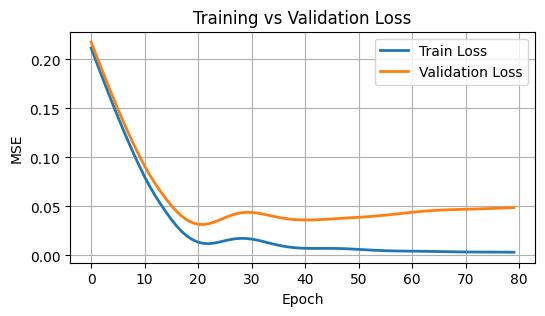

In [469]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6,3))

plt.plot(train_losses, label="Train Loss", linewidth=2)
plt.plot(val_losses, label="Validation Loss", linewidth=2)

plt.xlabel("Epoch")
plt.ylabel("MSE")
plt.title("Training vs Validation Loss")
plt.legend()
plt.grid(True)

plt.show()

In [472]:
model.load_state_dict(torch.load("models/model_epoch_45.pt", weights_only= True))
model.eval()


with torch.no_grad():
    all_preds = model(X_test_tensor)

mse = masked_mse_loss(all_preds, y_test_tensor, mask_test_tensor)

print("MAE:", mae)

MAE: tensor(0.0275)


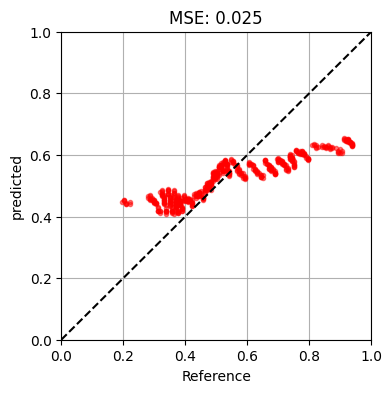

In [473]:
plt.figure(figsize = (4,4))
plt.plot(y_test_tensor, all_preds, '.r', alpha=0.5)
plt.plot([0,1], [0,1], 'k--')
plt.xlabel('Reference')
plt.ylabel('predicted')
plt.xlim(0,1)
plt.ylim(0,1)
plt.title(f'MSE: {mse:.3f}')
plt.grid()
